# Data Cleaning — `Tourist_Accommodation`

Limpieza de la tabla `Tourist_Accommodation` importada desde MySQL, partiendo de las conclusiones del EDA (`EDA_06_07_2026.ipynb y Data_Understanding_06_07_2026.pdf`).

**Puntos que se cubren:**
1. Corrección de tipos de datos
2. Eliminación o corrección de duplicados
3. Tratamiento de valores faltantes
4. Validación y corrección de valores atípicos
5. Estandarización de formatos

**Salida final:** un único CSV limpio (`../Data/clean_dataset_06_07_2026.csv`) sobre el que se aplicará la fase de *Data Transformation*.

> **Alcance de esta fase.** Aquí solo se limpia y se corrigen tipos/formatos. **NO** se hacen aquí (van en *Transformation*):
> - Reescalado de reseñas/puntuaciones: `review_scores_rating` 0–1000 → 0–100 y sub-puntuaciones 0–100 → 0–10 (lo hace Dídac).
> - Paso de `is_instant_bookable` a 0/1.
>
> No se elimina información salvo lo estrictamente necesario (versiones antiguas de un mismo alojamiento).

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)

In [2]:

def encontrar_raiz_proyecto(nombre_carpeta='Equip_34'):
    '''
    Función para encontrar la carpeta raíz del proyecto subiendo desde el directorio actual.
    '''
    actual = Path.cwd()
    for carpeta in [actual] + list(actual.parents):
        if carpeta.name == nombre_carpeta:
            return carpeta
    raise FileNotFoundError(f"No se encontró la carpeta '{nombre_carpeta}' subiendo desde {actual}")

raiz_proyecto = encontrar_raiz_proyecto('Equip_34')
ruta = raiz_proyecto / 'Data' / 'raw_dataset_06_07_2026.csv'

print(f"Ruta resuelta: {ruta}")
df_original = pd.read_csv(ruta)
df = df_original.copy()

Ruta resuelta: c:\Users\lacal\Desktop\IT_ACADEMY\simulador\ProjecteData\Equip_34\Data\raw_dataset_06_07_2026.csv


In [3]:
# Copia de trabajo para no alterar el DataFrame original importado
df_clean = df.copy()

## 1. Corrección de tipos de datos

- `bathrooms`,`beds`  y `bedrooms` llegan como `float64` aunque son recuentos → a entero nullable (`Int64`, admite nulos).
- Fechas (`first_review_date`, `last_review_date`, `insert_date`) están como texto `dd/mm/aaaa` → a `datetime`.


In [4]:
# --- Recuentos que venían como texto -> entero nullable (Int64) ---
count_cols = ['bathrooms', 'bedrooms', 'beds']
for col in count_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').astype('Int64')

# --- Fechas dd/mm/aaaa -> datetime ---
date_cols = ['first_review_date', 'last_review_date', 'insert_date']
for col in date_cols:
    df_clean[col] = pd.to_datetime(df_clean[col], format='%d/%m/%Y', errors='coerce')

df_clean[count_cols + date_cols].dtypes

bathrooms                     Int64
bedrooms                      Int64
beds                          Int64
first_review_date    datetime64[ns]
last_review_date     datetime64[ns]
insert_date          datetime64[ns]
dtype: object

In [5]:
# Comprobación: la conversión no debe crear nulos "nuevos" inesperados
print("Nulos tras convertir tipos (deben coincidir con los originales):")
for col in count_cols + date_cols:
    print(f"  {col:20s} nulos: {df_clean[col].isna().sum():5d}  |  original: {df[col].isna().sum()}")

Nulos tras convertir tipos (deben coincidir con los originales):
  bathrooms            nulos:    43  |  original: 43
  bedrooms             nulos:    39  |  original: 39
  beds                 nulos:     8  |  original: 8
  first_review_date    nulos:  1614  |  original: 1614
  last_review_date     nulos:  1615  |  original: 1615
  insert_date          nulos:     0  |  original: 0


## 2. Eliminación o corrección de duplicados

No hay filas completamente idénticas, pero sí `apartment_id` repetidos: el mismo alojamiento volcado en fechas distintas. Se conserva únicamente la **última foto** (máximo `insert_date`) de cada `apartment_id`.

In [6]:
# Filas 100% duplicadas
print("Filas completamente duplicadas:", df_clean.duplicated().sum())

# apartment_id repetidos (mismo alojamiento en distintos volcados)
rep = df_clean['apartment_id'].value_counts()
rep = rep[rep > 1]
print(f"apartment_id repetidos: {rep.shape[0]}  (filas implicadas: {int(rep.sum())})")
print("Fecha global mas reciente de volcado (insert_date):", df_clean['insert_date'].max().date())

# Nos quedamos con el registro de mayor insert_date por apartment_id
antes = len(df_clean)
df_clean = (
    df_clean.sort_values('insert_date')
            .drop_duplicates(subset='apartment_id', keep='last')
            .reset_index(drop=True)
)
print(f"\nRegistros eliminados (versiones antiguas): {antes - len(df_clean)}")
print("Dimensiones tras deduplicar:", df_clean.shape)
print("apartment_id unico ahora?", df_clean['apartment_id'].is_unique)

Filas completamente duplicadas: 0
apartment_id repetidos: 299  (filas implicadas: 606)
Fecha global mas reciente de volcado (insert_date): 2021-02-27

Registros eliminados (versiones antiguas): 307
Dimensiones tras deduplicar: (7693, 35)
apartment_id unico ahora? True


## 3. Tratamiento de valores faltantes

Se **conservan** los registros con nulos (no se eliminan) y **no se imputan** valores que puedan sesgar los análisis posteriores:

- `review_scores_*`, `first_review_date`, `last_review_date`, `reviews_per_month`: nulos **estructurales** = alojamientos sin reseñas (`number_of_reviews = 0`). Se dejan como nulos.
- `has_availability`: solo `VERDADERO` + nulos (no hay `FALSO`); los nulos se dejan como desconocido (no se convierten a falso). En este caso se creara columna de `has_availability`con valores 1 y 0 respetando los nulos
- `neighbourhood_district`, `price`, `bathrooms`, `bedrooms`, `beds`, `name`, `description`: se conservan sin imputar.

*(Si en Transformation se decide imputar `price` o tratar `has_availability`, se hará allí con criterio de negocio.)*

In [7]:
# Panorama de nulos tras deduplicar
nulos = pd.DataFrame({
    "nulos": df_clean.isnull().sum(),
    "%": (df_clean.isnull().mean() * 100).round(2)
})
nulos[nulos["nulos"] > 0].sort_values("%", ascending=False)

,nulos,%
neighbourhood_district,3024,39.31
review_scores_value,1649,21.44
review_scores_location,1649,21.44
review_scores_checkin,1648,21.42
review_scores_accuracy,1643,21.36
review_scores_communication,1639,21.31
review_scores_cleanliness,1637,21.28
review_scores_rating,1634,21.24
last_review_date,1555,20.21
first_review_date,1554,20.20


In [8]:
# Los nulos de valoraciones son estructurales: alojamientos sin reseñas
sin_reviews = df_clean['number_of_reviews'] == 0
print("Alojamientos con number_of_reviews == 0 :", sin_reviews.sum())
print("  de ellos con review_scores_rating nulo:", (sin_reviews & df_clean['review_scores_rating'].isna()).sum())
print("Con reseñas (>0) pero rating nulo (nulo real, no estructural):",
      ((~sin_reviews) & df_clean['review_scores_rating'].isna()).sum())

print("\nhas_availability (solo VERDADERO + nulos, sin FALSO):")
print(df_clean['has_availability'].value_counts(dropna=False))

Alojamientos con number_of_reviews == 0 : 1551
  de ellos con review_scores_rating nulo: 1551
Con reseñas (>0) pero rating nulo (nulo real, no estructural): 83

has_availability (solo VERDADERO + nulos, sin FALSO):
has_availability
VERDADERO    7159
NaN           534
Name: count, dtype: int64


In [9]:
# utilizamos Int64 para poder tener nulos en la columna numérica y obtener un tipo de dato entero, en lugar de float que es lo que obtendríamos con int64.
df_clean['has_availability_numeric'] = df_clean['has_availability'].map({'VERDADERO': 1, 'FALSO': 0}).astype('Int64')

print(df_clean['has_availability_numeric'].value_counts(dropna=False))
print(df_clean['has_availability'].value_counts(dropna=False))

df_clean[['has_availability', 'has_availability_numeric']].tail()

has_availability_numeric
1       7159
<NA>     534
Name: count, dtype: Int64
has_availability
VERDADERO    7159
NaN           534
Name: count, dtype: int64


,has_availability,has_availability_numeric
7688,VERDADERO,1
7689,VERDADERO,1
7690,VERDADERO,1
7691,VERDADERO,1
7692,VERDADERO,1


In [10]:
df_clean["reviews_per_month"].describe()

count    6139.000000
mean      124.895586
std       154.556071
min         1.000000
25%        17.000000
50%        58.000000
75%       180.000000
max      1273.000000
Name: reviews_per_month, dtype: float64

In [11]:
df_clean["reviews_per_month"].sort_values(ascending=False).head(10)

4703    1273.0
2367    1213.0
6054    1125.0
6217    1045.0
4251     952.0
995      938.0
4134     914.0
4122     911.0
3522     868.0
6387     868.0
Name: reviews_per_month, dtype: float64

## 4. Validación y corrección de valores atípicos

Confirmamos que los valores extremos son plausibles (no errores) y los **mantenemos**. Solo se revisa coherencia; no se elimina nada.

> `reviews_per_month` presenta valores muy altos (máx ≈ 1273). Parece estar escalado (×100) respecto al valor mensual real; **no se corrige aquí**, se revisará junto con el reescalado de reseñas en *Transformation*.

In [12]:
num_check = ['price', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
             'minimum_nights', 'maximum_nights', 'number_of_reviews', 'reviews_per_month']
df_clean[num_check].describe().round(2)

,price,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,number_of_reviews,reviews_per_month
count,7534.00,7693.00,7652.0,7654.0,7685.0,7693.00,7693.00,7693.00,6139.00
mean,1005.60,4.32,1.6,1.95,2.97,4.58,759.40,31.39,124.90
std,842.75,2.60,0.98,1.29,2.3,11.96,498.53,57.35,154.56
min,60.00,1.00,0.0,0.0,0.0,1.00,1.00,0.00,1.00
25%,450.00,2.00,1.0,1.0,1.0,1.00,61.00,1.00,17.00
50%,750.00,4.00,1.0,2.0,2.0,2.00,1125.00,8.00,58.00
75%,1220.00,6.00,2.0,3.0,4.0,4.00,1125.00,36.00,180.00
max,6071.00,29.00,12.0,16.0,30.0,365.00,1125.00,588.00,1273.00


In [13]:
# Recuento de outliers por IQR (solo informativo: NO se eliminan)
def n_outliers_iqr(s):
    s = s.dropna().astype(float)
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < low) | (s > high)).sum())

resumen_out = pd.Series({c: n_outliers_iqr(df_clean[c]) for c in num_check}, name='outliers_IQR')
print(resumen_out.to_string())

# Casos limite coherentes que SE CONSERVAN (pueden aportar info en otras columnas)
print("\nAlojamientos con beds == 0      :", int((df_clean['beds'] == 0).sum()), "(se conservan)")
print("Alojamientos con bathrooms == 0 :", int((df_clean['bathrooms'] == 0).sum()), "(se conservan)")
print("price -> min:", df_clean['price'].min(), "| max:", df_clean['price'].max(), "| nulos:", int(df_clean['price'].isna().sum()))

price                572
accommodates          63
bathrooms            361
bedrooms              37
beds                 178
minimum_nights       431
maximum_nights         0
number_of_reviews    797
reviews_per_month    384

Alojamientos con beds == 0      : 80 (se conservan)
Alojamientos con bathrooms == 0 : 14 (se conservan)
price -> min: 60.0 | max: 6071.0 | nulos: 159


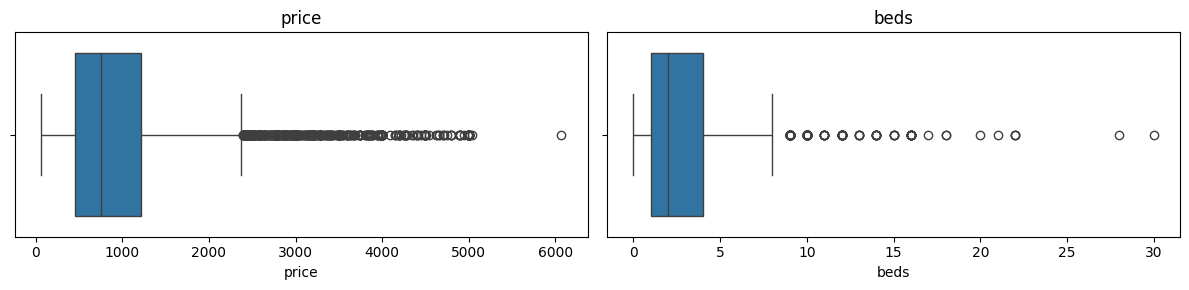

In [14]:
# Validacion visual de dos variables representativas (los outliers se mantienen)
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
sns.boxplot(x=df_clean['price'], ax=axes[0]); axes[0].set_title('price')
sns.boxplot(x=df_clean['beds'].astype('float'), ax=axes[1]); axes[1].set_title('beds')
plt.tight_layout(); plt.show()

## 5. Estandarización de formatos

- Se eliminan espacios sobrantes en los campos de texto.
- `price` → se renombra a **`price_€`** y se mantiene como numérico.
- **Aviso de codificación:** varios textos (`name`, `neighbourhood_name`, `description`) contienen el carácter de reemplazo `�` en lugar de acentos, perdidos al volcar los datos a MySQL (p. ej. `Cadaqu�s` → *Cadaqués*). **No es recuperable** a nivel de string. Se documenta como limitación de origen y se deja el texto tal cual; si se quisiera corregir habría que construir un diccionario manual en *Transformation*.

- Se detectan valores erróneos procedentes de la exportación (translation missing: en.hosting_amenity_49 y translation missing: en.hosting_amenity_50). Estos valores no representan comodidades reales, por lo que se eliminan de amenities_list conservando el resto de la información del alojamiento.
- Se normalizó la variable `amenities_list` eliminando entradas erróneas, corrigiendo inconsistencias de formato y unificando sinónimos para obtener una representación homogénea de las comodidades.
- se le quitó el acento a la categoria Malaga de `city`

In [15]:
# Espacios sobrantes en columnas de texto
text_cols = df_clean.select_dtypes(include=['object']).columns
for col in text_cols:
    df_clean[col] = df_clean[col].str.strip()

# price -> price_€ (se mantiene numerico)
df_clean = df_clean.rename(columns={'price': 'price_€'})
print("Columna de precio:", [c for c in df_clean.columns if 'price' in c], "| dtype:", df_clean['price_€'].dtype)

# Columna `city` pasa a ser mayuscula la primera letra
df_clean["city"] = df_clean["city"].str.strip().str.capitalize()

print("columna City cambiada: ", df_clean['city'])


Columna de precio: ['price_€'] | dtype: float64
columna City cambiada:  0       Barcelona
1       Barcelona
2       Barcelona
3       Barcelona
4       Barcelona
          ...    
7688       Malaga
7689       Girona
7690      Sevilla
7691      Sevilla
7692       Malaga
Name: city, Length: 7693, dtype: object


In [16]:
# Cuantificacion del problema de codificacion (informativo, no se altera el dato)
mojibake_cols = ['name', 'neighbourhood_name', 'description']
for col in mojibake_cols:
    n = df_clean[col].fillna('').str.contains('�').sum()
    print(f"{col:20s}: {n} registros con '�' (acento perdido en origen)")

name                : 1569 registros con '�' (acento perdido en origen)
neighbourhood_name  : 1681 registros con '�' (acento perdido en origen)
description         : 5269 registros con '�' (acento perdido en origen)


In [17]:
# Tratamiento de translation missing: en.hosting_amenity_49/50

# Comprobamos cuántos registros contienen "translation missing"

print(
    "Registros afectados:",
    df_clean["amenities_list"].str.contains(
        "translation missing",
        case=False,
        na=False
    ).sum()
)

Registros afectados: 927


In [18]:
# identificamos la existencia de los valores erroneos 
(df_clean.loc[
        df_clean["amenities_list"].str.contains(
            "translation missing",
            case=False,
            na=False
        ),
        "amenities_list"
    ]
    .str.extractall(r"(translation missing:[^,\]]+)")
    .value_counts())

0                                         
translation missing: en.hosting_amenity_50    841
translation missing: en.hosting_amenity_49    633
Name: count, dtype: int64

In [19]:
# eliminamos los valores erroneos

valores_eliminar = [
    "translation missing: en.hosting_amenity_49",
    "translation missing: en.hosting_amenity_50"
]

for token in valores_eliminar:
    df_clean["amenities_list"] = (
        df_clean["amenities_list"]
        .str.replace(token, "", regex=False)
    )

In [20]:
#eliminamos posibles , dobles que puedan quedar de la eliminacion
df_clean["amenities_list"] = (
    df_clean["amenities_list"]
        .str.replace(r"\s*,\s*,", ",", regex=True)
        .str.replace(r"^,\s*", "", regex=True)
        .str.replace(r",\s*$", "", regex=True)
        .str.replace(r"\s{2,}", " ", regex=True)
        .str.strip()
)

In [21]:
#en los casos en que quede vacia la lista, se convierten a nulos
df_clean["amenities_list"] = (
    df_clean["amenities_list"]
        .replace(r"^\s*$", pd.NA, regex=True)
)

In [22]:
#comprobacion eliminado
print(
    "Registros con 'translation missing':",
    df_clean["amenities_list"].str.contains(
        "translation missing",
        case=False,
        na=False
    ).sum()
)

print(
    "Registros con hosting_amenity:",
    df_clean["amenities_list"].str.contains(
        r"hosting_amenity_\d+",
        regex=True,
        na=False
    ).sum()
)

Registros con 'translation missing': 0
Registros con hosting_amenity: 0


In [23]:
#cuantos registros se convierten en nulos?
print(
    "Amenities_list nulas:",
    df_clean["amenities_list"].isna().sum()
)

Amenities_list nulas: 20


In [24]:
# limpieza de formato. eliminacion de `]`
df_clean["amenities_list"] = (
    df_clean["amenities_list"]
    .str.replace("]", "", regex=False)
)


In [25]:
# *Unificación de sinónimos en amenities_list*

# Obtener todas las amenities únicas

amenities = (
    df_clean["amenities_list"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

amenities.sort_values().unique()

array(['', '24-hour check-in', '40 HDTV', '43 HDTV with Netflix',
       'Accessible-height bed', 'Accessible-height toilet',
       'Air conditioning', 'Amazon Echo', 'BBQ grill', 'Baby bath',
       'Baby monitor', 'Baby safety gates', 'Babysitter recommendations',
       'Baking sheet', 'Balcony', 'Barbecue utensils', 'Bath towel',
       'Bathroom essentials', 'Bathtub', 'Bathtub with bath chair',
       'Beach essentials', 'Beach view', 'Beachfront', 'Bed linens',
       'Bedroom comforts', 'Bidet', 'Bluetooth sound system', 'Body soap',
       'Bread maker', 'Breakfast', 'Breakfast table', 'Building staff',
       'Buzzer/wireless intercom', 'Cable TV', 'Carbon monoxide alarm',
       'Carbon monoxide detector', 'Cat(s)', 'Ceiling fan',
       'Central air conditioning', 'Central heating', 'Changing table',
       "Chef's kitchen", 'Childrenu2019s books and toys',
       'Childrenu2019s dinnerware', 'Children�s books and toys',
       'Children�s dinnerware', 'Cleaning before che

In [26]:
# Estandarización de amenities_list
# - Sinónimos
# - Problemas de codificación
# - Diferencias de escritura


sinonimos = {

    # Sinónimos
    "Smoke detector": "Smoke alarm",
    "Carbon monoxide detector": "Carbon monoxide alarm",
    "Wireless Internet": "Wifi",

    # Capitalización
    "Self Check-In": "Self check-in",
    "Laptop-friendly workspace": "Laptop friendly workspace",
    "Doorman Entry": "Doorman",

    # Problemas de codificación
    "Children\\u2019s books and toys": "Children's books and toys",
    "Children�s books and toys": "Children's books and toys",

    "Children\\u2019s dinnerware": "Children's dinnerware",
    "Children�s dinnerware": "Children's dinnerware",

    "Pack \\u2019n Play/travel crib": "Pack 'n Play/travel crib",
    "Pack �n Play/travel crib": "Pack 'n Play/travel crib",

    "Wifi u2013 100 Mbps": "Wifi",
    "Washer u2013 In unit": "Washer",
    "Washer u2013u00a0In unit": "Washer",

    "Free driveway parking on premises u2013 1 space":
    "Free driveway parking on premises - 1 space",

    # Errores puntuales
    "43 HDTVwith Netflix": "43 HDTV with Netflix",
    "Pour Over Coffee": "Pour-over coffee",
    "Ski in/Ski out": "Ski-in/Ski-out",
    "smooth pathway to front door": "Smooth pathway to front door",
    "toilet": "Toilet"
}

for viejo, nuevo in sinonimos.items():
    df_clean["amenities_list"] = (
        df_clean["amenities_list"]
        .str.replace(viejo, nuevo, regex=False)
    )

In [27]:
# Eliminar espacios alrededor de las comas
df_clean["amenities_list"] = (
    df_clean["amenities_list"]
    .str.replace(r"\s*,\s*", ",", regex=True)
)

# Eliminar comas repetidas
df_clean["amenities_list"] = (
    df_clean["amenities_list"]
    .str.replace(r",\s*,+", ",", regex=True)
)

# Eliminar coma final
df_clean["amenities_list"] = (
    df_clean["amenities_list"]
    .str.replace(r",\s*$", "", regex=True)
    .str.strip()
)

In [28]:
amenities = (
    df_clean["amenities_list"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

# No deben quedar elementos vacíos
print("Amenities vacías:", (amenities == "").sum())

# Número de amenities distintas
print("Amenities únicas:", amenities.nunique())

# Frecuencias
amenities_df = (
    amenities
    .value_counts()
    .reset_index()
)

amenities_df.columns = ["Amenity", "Frecuencia"]

amenities_df

Amenities vacías: 5
Amenities únicas: 235


,Amenity,Frecuencia
0,Kitchen,7089
1,Wifi,6974
2,Essentials,6870
3,Washer,6556
4,TV,6490
...,...,...
230,Mosquito net,1
231,Bluetooth sound system,1
232,Drying rack for clothing,1
233,Outdoor shower,1


In [29]:
#convertimos las cadenas vacias a nulos
df_clean["amenities_list"] = (
    df_clean["amenities_list"]
    .replace(r"^\s*$", pd.NA, regex=True)
)

In [30]:
amenities = (
    df_clean["amenities_list"]
        .dropna()
        .str.split(",")
        .explode()
        .str.strip()
)

In [31]:
# confirmamos que no hay registros vacios
print("Amenities vacías:", (amenities == "").sum())
print("Amenities únicas:", amenities.nunique())

Amenities vacías: 0
Amenities únicas: 234


In [32]:
# Unificación del nombre de ciudad
df_clean["city"] = df_clean["city"].replace({
    "Malaga": "Málaga"
})

Se detectaron 5 registros donde la columna amenities_list contenía una cadena vacía ('') en lugar de un valor nulo. Se estandarizaron a NaN para representar  la ausencia de información y evitar generar una comodidad vacía durante la separación de la lista

## 6. Verificación final y exportación a CSV

Se genera un **único CSV** con el resultado de la limpieza, listo para la fase de *Data Transformation*.

In [33]:
print("Dimensiones finales:", df_clean.shape)
print("apartment_id unico :", df_clean['apartment_id'].is_unique)
print("Filas duplicadas   :", df_clean.duplicated().sum())
print("\nTipos de datos finales:")
df_clean.info()

Dimensiones finales: (7693, 36)
apartment_id unico : True
Filas duplicadas   : 0

Tipos de datos finales:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7693 entries, 0 to 7692
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   apartment_id                 7693 non-null   int64         
 1   name                         7690 non-null   object        
 2   description                  7643 non-null   object        
 3   host_id                      7693 non-null   int64         
 4   neighbourhood_name           7693 non-null   object        
 5   neighbourhood_district       4669 non-null   object        
 6   room_type                    7693 non-null   object        
 7   accommodates                 7693 non-null   int64         
 8   bathrooms                    7652 non-null   Int64         
 9   bedrooms                     7654 non-null   Int64         
 10  be

In [34]:
# Exportacion del CSV final (una sola tabla limpia) para Data Transformation
output_dir = Path('..') / 'Data'
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / 'clean_dataset_06_07_2026.csv'

# utf-8 (sin BOM) para un round-trip limpio con pandas en la fase siguiente
df_clean.to_csv(output_path, index=False, encoding='utf-8')

print("CSV limpio guardado en:", output_path.resolve())
print("Filas x columnas:", df_clean.shape)

CSV limpio guardado en: C:\Users\lacal\Desktop\IT_ACADEMY\simulador\ProjecteData\Equip_34\Data\clean_dataset_06_07_2026.csv
Filas x columnas: (7693, 36)
